# 🤖 Large Language Models

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SharifiZarchi/IntroAI/blob/main/Session_10/LLM/LLM_Tutorial_EN.ipynb) [![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https%3A%2F%2Fgithub.com%2FSharifiZarchi%2FIntroAI%2Fblob%2Fmain%2FSession_10%2FLLM%2FLLM_Tutorial_EN.ipynb)

The final session. In Session 9 you implemented a transformer layer; here you stack it, train it, and watch a language model appear. Then you drive a real one, give it knowledge, give it tools, and finish the course. The plan:

1. Train your own GPT, from the layer you built
2. A real assistant, and how to drive it
3. Retrieval: giving the model knowledge it lacks
4. An agent: giving the model tools and a loop
5. Scale, training stages, limits, and the course wrap-up

Prerequisites: the transformer layer, causal masking and softmax sampling (Session 9), and the PyTorch training loop (Sessions 7 and 8).

**Everything here runs on a free account.** No API key, no paid tier, no gated licence. On Colab, enable the GPU (*Runtime, Change runtime type, T4 GPU*) and Part 1 trains in about a minute; on CPU it takes about three. The assistant in Parts 2 to 4 is a 0.5B model, roughly 1 GB downloaded once.

**How to run:** click a cell and press `Shift + Enter`, in order, top to bottom. Every part ends with exercises.

---
# Part 1: Train your own GPT

A **language model** assigns a probability to the next token given the tokens so far. That is the entire objective, and generation is just repeated sampling from it: predict, draw a token, append, repeat.

The training data is any text, with no labels needed, because the next character of every position is its own label. We use the complete plays of Shakespeare (1.1 MB) and work at the **character** level, so the vocabulary is 65 symbols and training takes minutes:

In [1]:
import os
import time
import urllib.request
import torch
from torch import nn
import matplotlib.pyplot as plt
%matplotlib inline

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
if not os.path.exists("tinyshakespeare.txt"):
    urllib.request.urlretrieve(url, "tinyshakespeare.txt")
text = open("tinyshakespeare.txt", encoding="utf-8").read()

chars = sorted(set(text))
vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}

data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
split = int(0.9 * len(data))
train_data, val_data = data[:split], data[split:]

print("characters:", len(text), "| vocabulary:", vocab_size)
print("sample:", repr(text[:90]))

characters: 1115394 | vocabulary: 65
sample: 'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Ci'


### 1.1 The model
Three pieces, all from Session 9. A **token embedding** table turns each character id into a vector. A **position embedding** adds the position, because attention alone is order-blind. Then four **transformer layers**, identical to the class you wrote last session, except that the causal mask is now switched on so no position can read the future:

In [2]:
BLOCK, BATCH, D_MODEL, HEADS, LAYERS = 128, 64, 128, 4, 4

class TransformerLayer(nn.Module):
    def __init__(self, d_model, heads):
        super().__init__()
        self.attention = nn.MultiheadAttention(d_model, heads, batch_first=True)
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, 4 * d_model), nn.ReLU(), nn.Linear(4 * d_model, d_model))
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask):
        h = self.norm1(x)
        x = x + self.attention(h, h, h, attn_mask=mask, need_weights=False)[0]
        return x + self.feed_forward(self.norm2(x))


class TinyGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, D_MODEL)
        self.position_embedding = nn.Embedding(BLOCK, D_MODEL)
        self.layers = nn.ModuleList([TransformerLayer(D_MODEL, HEADS) for _ in range(LAYERS)])
        self.norm = nn.LayerNorm(D_MODEL)
        self.head = nn.Linear(D_MODEL, vocab_size)

    def forward(self, idx):
        T = idx.shape[1]
        mask = torch.triu(torch.ones(T, T, dtype=torch.bool, device=idx.device), diagonal=1)
        x = self.token_embedding(idx) + self.position_embedding(torch.arange(T, device=idx.device))
        for layer in self.layers:
            x = layer(x, mask)
        return self.head(self.norm(x))


device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
model = TinyGPT().to(device)

print("device:", device)
print("parameters:", sum(p.numel() for p in model.parameters()))

device: cpu
parameters: 826433


826,433 parameters, about six orders of magnitude smaller than a frontier model, and the architecture is the same one.

### 1.2 Batches and sampling
A training example is a window of 128 characters, and its label is the same window shifted by one, so every position predicts its own successor. Generation samples one character at a time from the model's output distribution, divided by a **temperature** that controls how sharp the distribution is:

In [3]:
def get_batch(source):
    idx = torch.randint(len(source) - BLOCK - 1, (BATCH,))
    x = torch.stack([source[i:i + BLOCK] for i in idx])
    y = torch.stack([source[i + 1:i + BLOCK + 1] for i in idx])
    return x.to(device), y.to(device)


@torch.no_grad()
def generate(model, seed="ROMEO:", n=200, temperature=0.8):
    model.eval()
    idx = torch.tensor([[stoi.get(c, 0) for c in seed]], device=device)
    for _ in range(n):
        logits = model(idx[:, -BLOCK:])[:, -1, :] / temperature
        probabilities = torch.softmax(logits, dim=-1)
        idx = torch.cat([idx, torch.multinomial(probabilities, 1)], dim=1)
    model.train()
    return "".join(itos[i] for i in idx[0].tolist())


x, y = get_batch(train_data)
print("input batch:", tuple(x.shape), "| target batch:", tuple(y.shape))
print("before training:", repr(generate(model, n=60)))

input batch: (64, 128) | target batch: (64, 128)
before training: "ROMEO:xXfUXuaEBX!,zMzVOCM'\nXsNN3DZdbTQ3ESH:f3 sNroxpMHKgXfrxqn;O; "


The untrained model emits noise, as it should: its weights are random.

### 1.3 Training
The loop is the one from Session 7, unchanged: forward, loss, backward, step. Every few hundred steps we print a sample, so the learning is visible as it happens:

In [4]:
STEPS = 2000 if device == "cuda" else 800          # keeps the runtime near a few minutes
CHECKPOINTS = [0, 200, STEPS // 2, STEPS]

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3)
history = []

start = time.time()
for step in range(STEPS + 1):
    if step in CHECKPOINTS:
        with torch.no_grad():
            vx, vy = get_batch(val_data)
            val_loss = loss_fn(model(vx).reshape(-1, vocab_size), vy.reshape(-1)).item()
        print(f"step {step:5d} | val loss {val_loss:.3f} | {time.time() - start:.0f}s")
        print(generate(model, n=110))
        print("-" * 70)

    x, y = get_batch(train_data)
    loss = loss_fn(model(x).reshape(-1, vocab_size), y.reshape(-1))
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    history.append(loss.item())

print(f"trained in {time.time() - start:.0f}s on {device}")

step     0 | val loss 4.315 | 0s
ROMEO:ZrvBQ$BAqeXTUfOy!SurMGIGFex,c3;ZMO:.sNEiimQ?hITIA&.g!BujFbchx-MYMDTM?NmDLTo$LhLsoBIBL!VXUBeqZ3-nra'bZP,j-V?wHh
----------------------------------------------------------------------


step   200 | val loss 2.122 | 37s
ROMEO:
Re Masteret so forsir, you, be halfor ance and Riall is morts
And innt for is and a cand by:
Tild licing; hom
----------------------------------------------------------------------


step   400 | val loss 1.828 | 72s
ROMEO:
Be't the heep, they noble to conse
The prison to the come say, contreed done.

PRIANPE:
And good sone man giv
----------------------------------------------------------------------


step   800 | val loss 1.691 | 143s
ROMEO:
Shall we he for the father it, and to not all thing.

NORTHUMBERLAND:
For, when are I say I should me the rem
----------------------------------------------------------------------


trained in 144s on cpu


Read the four samples in order, because that sequence is the whole point of the session.

At step 0 the output is random characters. By step 200 the model has learned the shape of English: pronounceable letter clusters, spaces in plausible places, and the layout of a play with a speaker name followed by a colon. By the middle checkpoint the words are mostly real and the lines scan like verse. At the end it writes dialogue with correct character names, punctuation and stage structure, from a model with under a million parameters trained for a few minutes on one megabyte of text.

Nobody told it about words, or names, or that a colon follows a speaker. All of it came from predicting the next character.

The loss curve, smoothed over 50 steps:

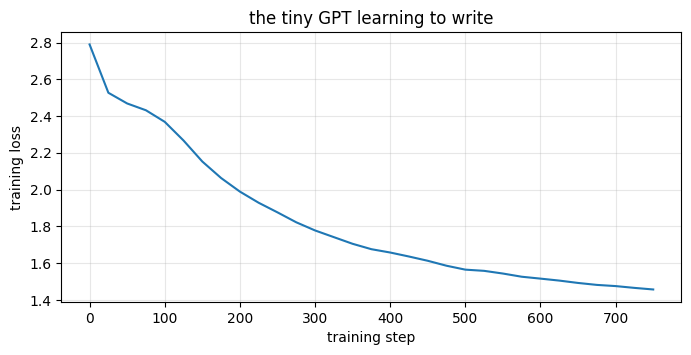

In [5]:
smoothed = torch.tensor(history).unfold(0, 50, 25).mean(dim=1)

plt.figure(figsize=(8, 3.5))
plt.plot(torch.arange(len(smoothed)) * 25, smoothed)
plt.xlabel("training step"); plt.ylabel("training loss")
plt.title("the tiny GPT learning to write")
plt.grid(alpha=0.3)
plt.show()

### 1.4 Temperature
Sampling divides the logits by a temperature before softmax. Low temperature sharpens the distribution and the model repeats its safest patterns; high temperature flattens it and the model invents:

In [6]:
for temperature in (0.2, 0.8, 1.5):
    print(f"=== temperature {temperature} ===")
    print(generate(model, n=140, temperature=temperature))
    print()

=== temperature 0.2 ===


ROMEO:
I am the words the provost of this death,
And there the death of the son of this face,
And the world to the world the stand of the world,
T

=== temperature 0.8 ===


ROMEO:
Where the hings we son, be in the desirect
Makingbries for their end bed are worls,
Where in the world heaven sorrows bird then borning me


=== temperature 1.5 ===


ROMEO:
Ah, welf.

GLOUCESTER:
I'll be villuanger virtue ked; must will
Undant: thou disces; make, to-killen?

RISTREM:
Call it you viqua, etimaze,



At 0.2 the text is repetitive and safe. At 0.8 it is varied but coherent. At 1.5 it produces invented words and broken names.

Here is the same effect in the numbers themselves. We take one genuinely uncertain position, the character after `"We are all "`, and redraw its distribution at each temperature:

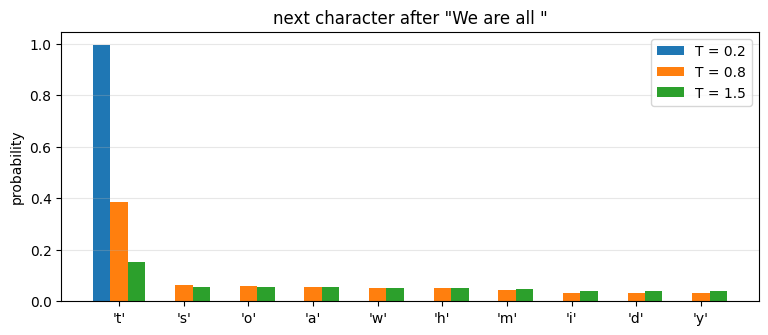

In [7]:
prompt = "First Citizen:\nWe are all "
with torch.no_grad():
    logits = model(torch.tensor([[stoi[c] for c in prompt]], device=device))[0, -1].cpu()

top = logits.topk(10).indices
width = 0.27

plt.figure(figsize=(9, 3.5))
for offset, temperature in zip((-width, 0, width), (0.2, 0.8, 1.5)):
    probabilities = torch.softmax(logits / temperature, dim=-1)[top]
    plt.bar(torch.arange(10) + offset, probabilities, width, label=f"T = {temperature}")
plt.xticks(range(10), [repr(itos[int(i)]) for i in top])
plt.ylabel("probability"); plt.title('next character after "We are all "')
plt.legend(); plt.grid(axis="y", alpha=0.3)
plt.show()

One set of logits, three different distributions. At T = 0.2 nearly all the mass collapses onto the single most likely character, so sampling is effectively deterministic and the model keeps saying its safest thing. At T = 1.5 the bars level out and characters the model rates as unlikely start winning draws, which is where the invented words come from.

Note that the ranking never changes, only the gaps between the bars. Temperature does not give the model new ideas, it changes how willing the sampler is to take the ideas the model already ranked low. Every chat interface exposes this exact knob, and now you know precisely what it does to the numbers.

### ✏️ Exercise 1
Look inside the prediction. For the prompt `"ROMEO:"`, take the model's output distribution for the next character and print the ten most likely characters with their probabilities. Which characters does it expect after a speaker name?

In [8]:
# ✏️ top-10 next characters



<details>
<summary>💡 Solution (click to open)</summary>

```python
context = torch.tensor([[stoi[c] for c in "ROMEO:"]], device=device)
with torch.no_grad():
    probs = torch.softmax(model(context)[0, -1], dim=-1)
top = probs.topk(10)
for p, i in zip(top.values, top.indices):
    print(f"{itos[int(i)]!r:6s} {p.item():.3f}")
```

The newline character dominates, followed by a space and common letters, because in the training text a speaker name is almost always followed by a line break. The model learned the format of a play, not just its words.

</details>

### ✏️ Exercise 2
Generate from three different seeds, for example `"JULIET:"`, `"To be, or"` and `"The king"`. Does the model stay in character? What happens with a seed containing characters it has never seen, such as digits?

In [9]:
# ✏️ your seeds



<details>
<summary>💡 Solution (click to open)</summary>

```python
for seed in ["JULIET:", "To be, or", "The king"]:
    print(f"=== {seed!r}")
    print(generate(model, n=120))
    print()
```

The model continues in the register of the seed, because the seed sets the context that attention reads. Characters outside the 65-symbol vocabulary cannot be encoded at all; our `stoi.get(c, 0)` silently maps them to the first character, which is the character-level version of the out-of-vocabulary problem that subword tokenizers solve in real models.

</details>

### ✏️ Exercise 3
Context length is a hyperparameter with a visible effect. Train a second model with `BLOCK = 16` instead of 128 for the same number of steps and compare its samples. Which kind of structure disappears first?

In [10]:
# ✏️ shorter context



<details>
<summary>💡 Solution (click to open)</summary>

```python
BLOCK_BACKUP = BLOCK
BLOCK = 16
torch.manual_seed(42)
short_model = TinyGPT().to(device)
short_opt = torch.optim.AdamW(short_model.parameters(), lr=3e-3)
for step in range(STEPS):
    x, y = get_batch(train_data)
    loss = loss_fn(short_model(x).reshape(-1, vocab_size), y.reshape(-1))
    short_opt.zero_grad(); loss.backward(); short_opt.step()
print(generate(short_model, n=140))
BLOCK = BLOCK_BACKUP
```

Words survive, because spelling needs only a few characters of context, but the long-range structure decays: speaker names appear in the wrong places and lines stop hanging together. Context length buys coherence, which is why frontier models fight so hard to extend it, against the quadratic cost you measured in Session 9.

</details>

### ✏️ Exercise 4
Sampling versus greedy decoding. Modify `generate` to always take the most likely character (`probabilities.argmax()`) instead of sampling, and compare the output with temperature 0.8. Why is greedy decoding a poor choice for creative text?

In [11]:
# ✏️ greedy decoding



<details>
<summary>💡 Solution (click to open)</summary>

```python
@torch.no_grad()
def generate_greedy(model, seed="ROMEO:", n=140):
    model.eval()
    idx = torch.tensor([[stoi.get(c, 0) for c in seed]], device=device)
    for _ in range(n):
        logits = model(idx[:, -BLOCK:])[:, -1, :]
        idx = torch.cat([idx, logits.argmax(dim=-1, keepdim=True)], dim=1)
    model.train()
    return "".join(itos[i] for i in idx[0].tolist())

print(generate_greedy(model))
```

Greedy decoding falls into loops, repeating the same phrase, because the most likely next character given a repetitive context is more of the same. Sampling is what keeps generated text alive, and temperature is the dial between the two behaviours.

</details>

---
# Part 2: A real assistant

Your model has 0.8 million parameters and read one megabyte. A production assistant has billions and read terabytes, but the objective and the architecture are the ones you just used.

We load **Qwen2.5-0.5B-Instruct**: 494 million parameters, Apache-2.0 licensed, no account or token required, about 1 GB downloaded once. It is small enough for a free notebook and already trained to follow instructions:

In [12]:
import os
os.environ["USE_TF"] = "0"

from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
llm = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device).eval()
if device == "cuda":
    llm = llm.half()                        # half precision is faster on a GPU

llm.generation_config.top_p = None          # we control sampling with temperature alone,
llm.generation_config.top_k = None          # so clear the packaged defaults and keep the
llm.generation_config.temperature = None    # output free of configuration warnings

print("parameters:", sum(p.numel() for p in llm.parameters()))
print("vocabulary:", tokenizer.vocab_size, "subword tokens")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


parameters: 494032768
vocabulary: 151643 subword tokens


### 2.1 The chat template
A base language model only continues text. An assistant is produced by wrapping the conversation in a fixed format with role markers, which the model was trained to follow. That format is what makes a system prompt possible:

In [13]:
messages = [{"role": "system", "content": "You are a helpful teacher."},
            {"role": "user", "content": "Explain gradient descent in one sentence."}]

print(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))

<|im_start|>system
You are a helpful teacher.<|im_end|>
<|im_start|>user
Explain gradient descent in one sentence.<|im_end|>
<|im_start|>assistant



The special tokens mark where each role starts and ends, and the final marker tells the model it is now the assistant's turn. Everything a chat interface does is build this string.

### 2.2 Talking to it
The helper below does exactly that and nothing more: build the string, turn it into token ids, generate, and decode only the newly generated part:

In [14]:
def chat(user_message, system="You are a helpful assistant. Answer in one short sentence.",
         max_new_tokens=60, temperature=0.7, do_sample=True):
    messages = [{"role": "system", "content": system},
                {"role": "user", "content": user_message}]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)
    settings = {"temperature": temperature} if do_sample else {}   # temperature only applies when sampling
    with torch.no_grad():
        out = llm.generate(ids, max_new_tokens=max_new_tokens, do_sample=do_sample,
                           pad_token_id=tokenizer.eos_token_id, **settings)
    return tokenizer.decode(out[0][ids.shape[1]:], skip_special_tokens=True).strip()


for question in ["What is the capital of France?",
                 "Explain gradient descent in one sentence."]:
    print("Q:", question)
    print("A:", chat(question), "\n")

Q: What is the capital of France?


A: Paris, the capital city of France. 

Q: Explain gradient descent in one sentence.


A: Gradient descent is an optimization algorithm used to minimize certain functions by iteratively adjusting parameters to find the lowest point in function space. 



### 2.3 The system prompt changes everything
Same question, three different instructions about who the model is:

In [15]:
question = "Why is the sky blue?"

for system in ["You are a physics professor. Answer in one technical sentence.",
               "You are talking to a five year old. Answer in one simple sentence.",
               "You are a poet. Answer in one line of verse."]:
    print(system)
    print("  ->", chat(question, system=system), "\n")

You are a physics professor. Answer in one technical sentence.


  -> The sky appears blue because sunlight scattered by particles in Earth's atmosphere bends and scatters into various colors, including blue from the primary color of light rather than white light. 

You are talking to a five year old. Answer in one simple sentence.


  -> The sky appears blue because sunlight scatters light particles, causing them to bend and spread out across the atmosphere. 

You are a poet. Answer in one line of verse.


  -> Whispers of smoke ascend, hues they craft, blue's hue so deep. 



### 2.4 Learning inside the prompt
Give the model two examples of a made-up format and it follows the pattern for a third input, with no training and no weight update. This is **in-context learning**, and it appeared on its own once models grew large enough:

In [16]:
few_shot = '''Convert the sentence into a command.

Sentence: I would like the light to be brighter.
Command: increase_brightness()

Sentence: It is too loud in here.
Command: decrease_volume()

Sentence: The room is too cold.
Command:'''

print(chat(few_shot, system="You complete patterns exactly.", max_new_tokens=15, do_sample=False))

increase_temperature()


### 2.5 Where it fails
Two failures, both instructive. First, arithmetic:

In [17]:
print("model:", chat("What is 4321 * 1234? Reply with only the number.", max_new_tokens=30))
print("truth:", 4321 * 1234)

model: 5,086,764
truth: 5332114


The model produces a confident number that is wrong, because multiplication is not a pattern that next-token prediction learns reliably. Part 4 fixes this with a tool.

Second, Persian. The same question in English and in Persian:

In [18]:
print("EN:", chat("What is artificial intelligence? Answer in one sentence."), "\n")
print("FA:", chat("هوش مصنوعی چیست؟ در یک جمله توضیح بده."))

EN: Artificial intelligence refers to the science of creating machines that can perform tasks typically associated with human intelligence, such as learning and recognizing patterns from data. 



FA: اوشی مصنوعی هر دفتر.


The English answer is fluent and the Persian answer degrades badly, sometimes into broken words. The reason is data: this model saw far more English than Persian during pretraining, and a 0.5B model has little capacity to spare for a low-resource language. Larger multilingual models do much better, but the gap is real at every scale, and closing it for Persian requires Persian data and Persian benchmarks. That is an open field, and it is one of the most useful things a graduate of this course can work on.

### ✏️ Exercise 5
Write a system prompt that makes the model answer every question with another question, in the style of a Socratic teacher, and test it on two questions.

In [19]:
# ✏️ your system prompt



<details>
<summary>💡 Solution (click to open)</summary>

```python
socratic = "You are a Socratic teacher. Never answer directly. Reply with one guiding question."
for q in ["What is overfitting?", "Why do we split data into train and test?"]:
    print("Q:", q)
    print("A:", chat(q, system=socratic), "\n")
```

A small model follows the instruction imperfectly and sometimes answers anyway. Instruction following is a capability that grows with scale, which is one reason large assistants feel more obedient than small ones.

</details>

### ✏️ Exercise 6
Measure what temperature does to a real assistant. Ask the same question five times at `temperature=0.2` and five times at `temperature=1.5`, and compare how many distinct answers you get.

In [20]:
# ✏️ diversity versus temperature



<details>
<summary>💡 Solution (click to open)</summary>

```python
for temperature in (0.2, 1.5):
    answers = {chat("Give me a name for a pet cat.", max_new_tokens=12, temperature=temperature)
               for _ in range(5)}
    print(f"temperature {temperature}: {len(answers)} distinct answers")
    for a in answers:
        print("   ", a)
```

Low temperature returns nearly the same answer every time, high temperature returns five different ones and sometimes something incoherent. This is the same trade-off you saw on your own model in Part 1, at a different scale.

</details>

### ✏️ Exercise 7
Test in-context learning with a format of your own invention, for example turning a sentence into a JSON object with two fields. Two examples, then a third input. Does the model keep the format exactly?

In [21]:
# ✏️ your few-shot prompt



<details>
<summary>💡 Solution (click to open)</summary>

```python
prompt = '''Extract the fields.

Text: The meeting is on Monday at 9.
JSON: {"day": "Monday", "time": "9"}

Text: Lunch is on Friday at 12.
JSON: {"day": "Friday", "time": "12"}

Text: The exam is on Sunday at 8.
JSON:'''
print(chat(prompt, system="You complete patterns exactly.", max_new_tokens=25, do_sample=False))
```

The model usually reproduces the structure correctly, because the pattern is explicit in the context window. This is the mechanism behind most practical prompt engineering: showing beats describing.

</details>

---
# Part 3: Retrieval, giving the model knowledge

The model knows only what its weights absorbed during training. Ask it about something outside that, and it does not say "I do not know", it produces a fluent guess, because fluent continuation is exactly what it was trained for.

The standard fix is **retrieval augmented generation**: keep the facts in a document collection, find the relevant one, and put it in the prompt. Here is a small collection about this course, which no model has ever read:

In [22]:
from transformers import AutoModel, logging as hf_logging

hf_logging.set_verbosity_error()      # BERT here is used without its pretraining head,
                                      # so silence the report about those unused weights

documents = [
    "The IntroAI course has ten sessions and is taught by Ali Sharifi Zarchi on YouTube.",
    "Session 8 of the IntroAI course covers computer vision: convolution, CNNs and transfer learning.",
    "Session 9 of the IntroAI course covers word embeddings, the transformer layer, and a Kaggle competition on disaster tweets.",
    "Every IntroAI notebook is published in both Persian and English in the SharifiZarchi repository on GitHub.",
    "Gradient descent is the connecting thread of the IntroAI course, from linear regression to language models.",
]

encoder_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
encoder = AutoModel.from_pretrained("bert-base-uncased").to(device).eval()

def embed(texts):
    batch = encoder_tokenizer(texts, padding=True, truncation=True, max_length=64,
                              return_tensors="pt").to(device)
    with torch.no_grad():
        hidden = encoder(**batch).last_hidden_state
    mask = batch["attention_mask"].unsqueeze(-1)
    vectors = (hidden * mask).sum(dim=1) / mask.sum(dim=1)
    return (vectors / vectors.norm(dim=1, keepdim=True)).cpu()

document_vectors = embed(documents)
print("document vectors:", tuple(document_vectors.shape))

document vectors: (5, 768)


Retrieval is the cosine similarity of Session 9, nothing more: embed the question, compare it with every document, take the best match. Then compare the answer with and without that context:

In [23]:
def retrieve(question):
    scores = document_vectors @ embed([question])[0]
    best = int(scores.argmax())
    return documents[best], float(scores[best])


for question in ["Which session of the IntroAI course covers computer vision?",
                 "In which two languages are the IntroAI notebooks published?"]:
    passage, score = retrieve(question)
    print("Q:", question)
    print("  without context:", chat(question, max_new_tokens=40, do_sample=False))
    print(f"  retrieved (score {score:.2f}): {passage}")
    print("  with context   :", chat(f"Context: {passage}\n\nQuestion: {question}",
                                     max_new_tokens=40, do_sample=False), "\n")

Q: Which session of the IntroAI course covers computer vision?


  without context: The first session of the IntroAI course covers computer vision.
  retrieved (score 0.82): Session 8 of the IntroAI course covers computer vision: convolution, CNNs and transfer learning.


  with context   : Session 8 of the IntroAI course covers computer vision. 

Q: In which two languages are the IntroAI notebooks published?


  without context: The IntroAI notebooks are published in English and German.
  retrieved (score 0.73): Every IntroAI notebook is published in both Persian and English in the SharifiZarchi repository on GitHub.


  with context   : The IntroAI notebooks are published in both Persian and English in the SharifiZarchi repository on GitHub. 



Without context the model invents: it places computer vision in the first session and claims the notebooks are in English and German. With one retrieved sentence in the prompt, both answers are correct.

Nothing about the model changed. The weights are identical; only the context is different. This is why retrieval is the first thing added to almost every production system built on a language model, and why a search index plus a small model often beats a large model alone.

### ✏️ Exercise 8
Add three documents of your own about a topic the model cannot know, such as your city, your university department, or a personal project, and ask a question that only your documents can answer.

In [24]:
# ✏️ your documents and question



<details>
<summary>💡 Solution (click to open)</summary>

```python
my_documents = documents + [
    "The IntroAI final session builds a tiny GPT, an assistant, a retrieval system and an agent.",
    "The IntroAI Kaggle notebook reaches an F1 score of about 0.82 with a fine-tuned transformer.",
]
document_vectors = embed(my_documents)
documents = my_documents

question = "What F1 score does the IntroAI Kaggle notebook reach?"
passage, score = retrieve(question)
print("without:", chat(question, max_new_tokens=40, do_sample=False))
print("with   :", chat(f"Context: {passage}\n\nQuestion: {question}", max_new_tokens=40, do_sample=False))
```

The pattern holds: retrieval turns a guessing machine into a system that answers from evidence you control. Everything else in a production RAG system is engineering around this core, such as splitting long documents, indexing millions of vectors, and returning several passages instead of one.

</details>

### ✏️ Exercise 9
Break it. Ask a question whose answer is in none of the documents and inspect the retrieval score and the answer. What should a well-built system do when the best score is low?

In [25]:
# ✏️ an out-of-scope question



<details>
<summary>💡 Solution (click to open)</summary>

```python
question = "What is the price of a train ticket from Tehran to Isfahan?"
passage, score = retrieve(question)
print(f"best score {score:.2f}: {passage}")
print("answer:", chat(f"Context: {passage}\n\nQuestion: {question}", max_new_tokens=40, do_sample=False))
```

Retrieval always returns its best match, even when nothing is relevant, and the model then answers from an unrelated passage. A well-built system sets a similarity threshold and replies that it does not know when nothing clears it. Retrieval reduces hallucination, it does not remove it.

</details>

---
# Part 4: An agent, giving the model tools

Part 2 showed the model failing at arithmetic. It will never be reliable at it, and it does not need to be: a calculator is one line of Python. An **agent** is a language model in a loop with tools it can call.

The loop has four steps. The model receives a question and a description of its tools; it replies with either a tool call or a final answer; if it called a tool, we run the tool and feed the result back; repeat until it answers or a step limit is reached.

The tool descriptions live in the system prompt, and the example at the end matters more than it looks:

In [26]:
import re

TOOL_PROMPT = '''You are an assistant that can use tools.

Available tools:
calculator(expression) - evaluates a Python arithmetic expression

To use a tool, reply with exactly one line:
ACTION: calculator("EXPRESSION")

When you know the answer, reply with exactly one line:
ANSWER: your answer

Example:
User: What is 25 * 4?
ACTION: calculator("25 * 4")
Observation: 100
ANSWER: 100'''


def calculator(expression):
    return eval(expression, {"__builtins__": {}}, {})       # arithmetic only, no names available


def step(messages, max_new_tokens=40):
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)
    with torch.no_grad():
        out = llm.generate(ids, max_new_tokens=max_new_tokens, do_sample=False,
                           pad_token_id=tokenizer.eos_token_id)
    reply = tokenizer.decode(out[0][ids.shape[1]:], skip_special_tokens=True).strip()
    return reply.split(chr(10))[0].strip()                  # keep only the first line

print("agent parts ready ✅")

agent parts ready ✅


Keeping only the first line is not a detail, it is what makes the loop work. Left to itself the model writes the action *and* an invented observation *and* an answer in one breath, so it never sees the real tool output. Cutting at the first line forces it to stop and wait. Real agent frameworks do exactly this with stop sequences.

Now the loop:

In [27]:
def run_agent(question, max_steps=4, verbose=True):
    messages = [{"role": "system", "content": TOOL_PROMPT},
                {"role": "user", "content": question}]

    for _ in range(max_steps):
        reply = step(messages)
        if verbose:
            print("  model:", reply)

        call = re.search(r'ACTION:\s*calculator\("([^"]+)"\)', reply)
        if not call:
            answer = re.search(r"ANSWER:\s*(.+)", reply)
            return answer.group(1).strip() if answer else reply

        try:
            observation = calculator(call.group(1))
        except Exception as error:
            observation = f"error: {error}"
        if verbose:
            print("  tool :", observation)

        messages.append({"role": "assistant", "content": reply})
        messages.append({"role": "user", "content": f"Observation: {observation}"})

    return None


print("Q: What is 4321 * 1234?")
answer = run_agent("What is 4321 * 1234?")
print("FINAL:", answer)
print("truth:", 4321 * 1234)

Q: What is 4321 * 1234?


  model: ACTION: calculator("4321 * 1234")
  tool : 5332114


  model: The result of 4321 * 1234 is 5332114.
FINAL: The result of 4321 * 1234 is 5332114.
truth: 5332114


The trace shows the whole mechanism: the model recognizes that it needs arithmetic, writes a tool call, the tool returns the exact product, and the model states it. The same model that guessed wrong in Part 2 is now correct, because it stopped doing the arithmetic itself.

A word problem works the same way, with the model choosing what to compute:

In [28]:
print("Q: A book costs 17 dollars. How much do 23 books cost?")
print("FINAL:", run_agent("A book costs 17 dollars. How much do 23 books cost?"))

Q: A book costs 17 dollars. How much do 23 books cost?


  model: ACTION: calculator("23 * 17")
  tool : 391


  model: The total cost for 23 books is 391 dollars.
FINAL: The total cost for 23 books is 391 dollars.


That is an agent: plan, call, observe, answer. Production systems add more tools (web search, code execution, databases), better formats (native tool-calling APIs instead of our regex), and larger models that plan several steps ahead. The loop stays the same shape.

### ✏️ Exercise 10
Watch it fail. Run the agent on `"What is 15% of 240?"` and read the trace. What exactly goes wrong, and is the failure in the planning or in the formatting?

In [29]:
# ✏️ the percentage question



<details>
<summary>💡 Solution (click to open)</summary>

```python
print("FINAL:", run_agent("What is 15% of 240?"))
```

The model writes `calculator("15% of 240")`, which is not valid Python, so the tool returns a syntax error. The model then repeats the same malformed call until the step limit. The planning is right, the formatting is wrong, and the model does not learn from the error message. Fixes, in increasing order of effort: describe the expected syntax more precisely in the tool prompt, add an example of a percentage, feed the error back with a correction hint, or use a larger model. This is what agent engineering actually consists of.

</details>

### ✏️ Exercise 11
Add a second tool. Write a `word_count(text)` function, describe it in the system prompt next to the calculator, extend the parser to recognize it, and ask a question that needs it.

In [30]:
# ✏️ your second tool



<details>
<summary>💡 Solution (click to open)</summary>

```python
TWO_TOOL_PROMPT = TOOL_PROMPT.replace(
    'calculator(expression) - evaluates a Python arithmetic expression',
    'calculator(expression) - evaluates a Python arithmetic expression\n'
    'word_count(text) - counts the words in a piece of text')

def run_two_tool_agent(question, max_steps=4):
    messages = [{"role": "system", "content": TWO_TOOL_PROMPT},
                {"role": "user", "content": question}]
    for _ in range(max_steps):
        reply = step(messages)
        print("  model:", reply)
        call = re.search(r'ACTION:\s*(calculator|word_count)\("([^"]+)"\)', reply)
        if not call:
            answer = re.search(r"ANSWER:\s*(.+)", reply)
            return answer.group(1).strip() if answer else reply
        name, argument = call.group(1), call.group(2)
        observation = calculator(argument) if name == "calculator" else len(argument.split())
        print("  tool :", observation)
        messages.append({"role": "assistant", "content": reply})
        messages.append({"role": "user", "content": f"Observation: {observation}"})
    return None

print(run_two_tool_agent('How many words are in "the quick brown fox jumps over the lazy dog"?'))
```

With two tools the model must also choose *which* tool, and a 0.5B model sometimes chooses wrong. Tool selection is the first thing that degrades as the tool list grows, which is why production agents group tools and retrieve the relevant ones instead of listing all of them.

</details>

### ✏️ Exercise 12
Remove the worked example from `TOOL_PROMPT` (the last four lines) and rerun the multiplication question. How often does the model still produce a valid tool call?

In [31]:
# ✏️ prompt ablation



<details>
<summary>💡 Solution (click to open)</summary>

```python
SHORT_PROMPT = TOOL_PROMPT.split("Example:")[0].strip()
messages = [{"role": "system", "content": SHORT_PROMPT},
            {"role": "user", "content": "What is 4321 * 1234?"}]
print(step(messages))
```

Without the example the model usually stops calling the tool at all and answers from its head, wrongly. The example is the difference between a working agent and a broken one, which is the strongest possible demonstration that for small models, showing the format beats describing it.

</details>

---
# Part 5: Scale, stages, and the end of the course

Everything separating your Part 1 model from a frontier assistant fits in one table:

| | your tiny GPT | Qwen2.5-0.5B | frontier models |
|---|---|---|---|
| parameters | 826 thousand | 494 million | hundreds of billions |
| training text | 1 MB | terabytes | terabytes |
| training cost | minutes on a laptop | thousands of GPU hours | tens of millions of dollars |
| architecture | 4 transformer layers | 24 transformer layers | dozens to hundreds |
| objective | predict the next token | predict the next token | predict the next token |

The last row never changes. That is the point of this session.

**The three stages of building an assistant.** Pretraining is what you did in Part 1, at scale: next-token prediction on raw text, which is where the knowledge comes from. Instruction tuning continues training on curated instruction and response pairs, which is what turns a text continuer into something that answers questions. Reinforcement learning from human feedback then ranks candidate answers by human preference and pushes the weights toward the preferred ones. Look at the shape of that last stage: generate, get scored, adjust, repeat. It is the guess, error, correct loop from Session 2, with human preference as the error signal.

**What none of it changes.** The model remains a next-token predictor. It hallucinates, less than a 0.5B model but never zero, which is why Part 3 exists. It cannot do reliable arithmetic, which is why Part 4 exists. It inherits the biases of its training text, as Session 1 warned and the Persian gap in Part 2 illustrated. And fluency is not evidence of correctness, which is the single most useful thing to remember when using these systems.

### Does it understand?

This is the open question of the moment, and after this session you are in a position to hold an informed opinion rather than a borrowed one.

One side calls a language model a statistical parrot: it reproduces patterns found in text, has no experience of the world and no intentions, and its strange failures are exactly what not understanding looks like. You have two of those failures on screen: the confident wrong product in Part 2, and the model in Exercise 10 repeating a malformed tool call while the error message sits right in front of it.

The other side argues that predicting the next token well enough, at sufficient scale, forces a model to build internal structure that has earned the name understanding, and points to abilities nobody trained for, such as the in-context learning you used in Part 2.4, which appeared on its own as models grew.

The honest answer is that the question is unsettled, and that it will be settled by measurement rather than by intuition on either side. What is not in doubt is what you built: a next-token predictor, four layers, attention, gradient descent. Whether that machinery, scaled a millionfold, amounts to understanding is a question the field has not answered, and you are now equipped to follow the argument.

### ✏️ Exercise 13: the closing puzzle
Continue the sequence: **1, 11, 21, 1211, 111221, ?**

Each term describes the previous one out loud. Solve it yourself first, then ask the assistant and compare. Where does the model go wrong, and does putting the rule in the prompt rescue it?

In [32]:
# ✏️ the sequence puzzle



<details>
<summary>💡 Solution (click to open)</summary>

```python
puzzle = "Continue the sequence and explain the rule: 1, 11, 21, 1211, 111221, ?"
print("no hint  :", chat(puzzle, max_new_tokens=60, do_sample=False))
print("with hint:", chat(puzzle + " Hint: each term reads the previous term out loud.",
                         max_new_tokens=60, do_sample=False))
```

The answer is **312211**, because the previous term 111221 reads out loud as "three ones, two twos, one one". A 0.5B model essentially never finds this, because the step requires counting and grouping rather than completing a pattern, and the hint helps only sometimes. Larger models solve it, and many of them still get the term after it wrong.

It is a fitting last exercise, because it looks like language and is really arithmetic, which is precisely the seam this session has been prying at.

</details>

### The ten sessions, in one thread

| sessions | what you built | the new idea |
|---|---|---|
| 1 and 2 | what AI is, how it learns | data instead of rules |
| 3 and 4 | features, labels, a fitted line | loss and gradient descent |
| 5 and 6 | trees, forests, boosting, validation | generalization and honest measurement |
| 7 | a neural network from scratch | backpropagation |
| 8 | convolutional networks | architecture matched to the data |
| 9 | embeddings and the transformer layer | attention |
| 10 | a GPT, an assistant, retrieval, an agent | scale |

From fitting a line to Tehran house prices to running an agent that calls tools, the machinery never changed: a guess, an error, a gradient, a step. What changed was the architecture around it and the scale beneath it. Every link in that chain is now something you have implemented, trained and inspected yourself.

**Where to go next.** The [Hugging Face course](https://huggingface.co/learn) for modern practice, [fast.ai](https://course.fast.ai) for applied depth, Stanford CS231n and CS224n for theory, and Kaggle for the habit this course tried to build: measure, look at the errors, improve, repeat.

And the most useful thing you can do in Persian: build datasets, benchmarks and models for a language that has far fewer of them than it deserves. You saw the gap yourself in Part 2.

### ✏️ Exercise 14: final homework
1. Train the Part 1 model on a different text: a Persian poetry collection, a book from [Project Gutenberg](https://www.gutenberg.org), your own writing. Same code, different data, and the samples take on the voice of the source.
2. Give the agent a third tool of real use to you, such as a lookup over the documents from Part 3, so it can both retrieve and compute in one loop.
3. Take one factual claim an assistant made to you this week and verify it against a primary source. Make that a habit rather than an exercise.

The course ends where it started, with the opposite of magic: nothing in these systems is beyond understanding, and every part of them is now something you have built. 🎓